## Vector Embeddings


Hello I am Saksham

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
word_embeddings = {
    "cat":[0.8,0.6],
    "kitten":[0.7,0.5],
    "dog":[0.1,0.9],
    "puppy":[0.2,0.8],
    "car":[-0.5,0.2],
    "truck":[-0.6,0.15],
}

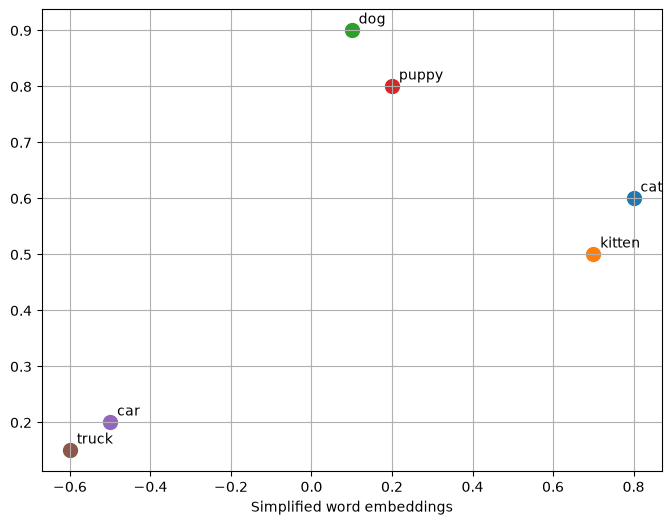

In [3]:
fig,ax=plt.subplots(figsize=(8,6))

for word,coords in word_embeddings.items():
    ax.scatter(coords[0],coords[1],s=100)
    ax.annotate(word,(coords[0],coords[1]),xytext=(5,5),textcoords="offset points")
ax.set_xlabel("Simplified word embeddings")
ax.grid(True)



In [4]:
## Measuring similarity using Cosine

def cosine_similiarity(vec1,vec2):
    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a*norm_b)

cat_similar=cosine_similiarity(word_embeddings["cat"],word_embeddings["kitten"])
print(cat_similar)

0.9997296931968457


# Create Embeddings

In [6]:
from langchain_huggingface import HuggingFaceEmbeddings


In [7]:
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"

)
embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\kanha\OneDrive\Documents\RAG practice\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kanha\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [8]:
text="Hello I am learning about embeddings"

k=embeddings.embed_query(text)
print(f"Text:{text}")
print("Emb length",{len(k)})
print(f"Embeddings {k}")

Text:Hello I am learning about embeddings
Emb length {384}
Embeddings [-0.007934672757983208, -0.09170757234096527, -0.004742992576211691, -0.004440759774297476, 0.010724092833697796, 0.07318361848592758, 0.01412670873105526, 0.01658197119832039, 0.04704888537526131, -0.027279922738671303, 0.027608418837189674, 0.060199230909347534, 0.04820089787244797, 0.0033472427166998386, -0.05125785619020462, 0.021345816552639008, 0.04995126277208328, 0.07593207061290741, -0.07687739282846451, -0.008240781724452972, -0.029051493853330612, -0.0500960499048233, -0.0036394507624208927, -0.09496802091598511, 0.01879897713661194, -0.023366278037428856, -0.02464323490858078, 0.0480102114379406, 0.10514664649963379, -0.05323880910873413, 0.039965711534023285, -0.04768766090273857, -0.016098104417324066, 0.061894554644823074, -0.07510852813720703, 0.11249526590108871, 0.0443122535943985, -0.0069813597947359085, -0.08516157418489456, -0.001931754290126264, 0.02246931567788124, 0.019911300390958786, -0.0291

## OpenAI